# Day 17: Text Embeddings & Semantic Search

## AI Internship – Xeven 2026

**Name:** Areeba Amjad  
**Date:** 21 August 2026  
**Topic:** Text Embeddings & Semantic Search 

## Objective

The objective of this notebook is to understand text embeddings and semantic search.

### Topics Covered

- What are text embeddings?
- How embeddings work
- Embedding models
- Vector dimensions
- Similarity metrics
- Semantic search
- Use cases of embeddings
- Vector databases
- Practical semantic search implementation

## 1. What Are Text Embeddings?

Text embeddings are numerical vector representations of text.

An embedding converts text into a high-dimensional vector containing numerical values that represent semantic information.

For example:

"Python is a programming language"

and

"Python is used for software development"

have different words, but their meanings are related. A good embedding model represents these texts with vectors that are relatively close to each other in vector space.

In simple terms:

Text → Embedding Model → Numerical Vector

Embeddings allow computers to compare the meaning of text mathematically.

### Example

A sentence may be represented conceptually as:

[0.21, -0.43, 0.87, 0.15, ...]

Real embedding models normally produce hundreds or thousands of dimensions.

## 2. How Embeddings Work

A neural network-based embedding model processes text and converts it into a vector in a high-dimensional space.

The general process is:

1. Input text is tokenized.
2. Tokens are processed by a neural network.
3. The model learns contextual and semantic relationships.
4. The information is encoded into a numerical vector.
5. Similar meanings tend to produce vectors that are close together.

### Concept

                Text
                  ↓
             Tokenization
                  ↓
          Neural Network Model
                  ↓
             Embedding
                  ↓
        [0.12, -0.45, 0.78, ...]
                  ↓
          Vector Space

If two texts have similar meanings, their vectors should generally be closer together.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


## 3. Embedding Models

Different models produce embeddings with different dimensions and capabilities.

### OpenAI Embedding Models

Examples include:

- text-embedding-3-small
- text-embedding-3-large

The `text-embedding-3-small` model has a default embedding size of 1536 dimensions.

The `text-embedding-3-large` model has a default embedding size of 3072 dimensions.

OpenAI's embedding models can also support reduced dimensions for certain use cases.

### Why Dimensions Matter

Higher dimensional vectors can represent more information, but they also require more storage and computational resources.

Therefore, the choice of embedding model and dimension depends on:

- Accuracy requirements
- Storage requirements
- Search speed
- Application size
- Cost

## 4. Similarity Metrics

After converting text into vectors, we need a mathematical method to determine how similar two vectors are.

Three common similarity/distance metrics are:

1. Cosine Similarity
2. Dot Product
3. Euclidean Distance

### 4.1 Cosine Similarity

Cosine similarity measures the angle between two vectors.

Formula:

cosine_similarity(A, B) =
(A · B) / (||A|| × ||B||)

A higher cosine similarity generally means the vectors have similar directions.

It is commonly used for semantic text comparison.

### 4.2 Dot Product

Dot product multiplies corresponding elements and sums the results.

A higher value can indicate greater similarity, depending on the model and normalization.

### 4.3 Euclidean Distance

Euclidean distance measures the straight-line distance between two vectors.

Smaller distance means the vectors are closer.

### Summary

Cosine Similarity → Higher is more similar

Dot Product → Higher is generally more similar

Euclidean Distance → Lower is more similar

In [2]:
def cosine_similarity(vector_a, vector_b):
    vector_a = np.array(vector_a)
    vector_b = np.array(vector_b)

    return np.dot(vector_a, vector_b) / (
        np.linalg.norm(vector_a) * np.linalg.norm(vector_b)
    )


def euclidean_distance(vector_a, vector_b):
    vector_a = np.array(vector_a)
    vector_b = np.array(vector_b)

    return np.linalg.norm(vector_a - vector_b)


vector_a = [1, 2, 3]
vector_b = [1, 2, 4]

print("Vector A:", vector_a)
print("Vector B:", vector_b)

print("\nCosine Similarity:",
      cosine_similarity(vector_a, vector_b))

print("Euclidean Distance:",
      euclidean_distance(vector_a, vector_b))

Vector A: [1, 2, 3]
Vector B: [1, 2, 4]

Cosine Similarity: 0.9914601339836675
Euclidean Distance: 1.0


## 5. Comparing Similar and Different Text

Before using a real embedding model, we can understand the idea with simple example vectors.

If two vectors point in similar directions, their cosine similarity will be high.

If vectors point in very different directions, their similarity will be lower.

In [3]:
similar_a = [0.8, 0.7, 0.6]
similar_b = [0.7, 0.8, 0.6]

different_a = [0.8, 0.7, 0.6]
different_b = [-0.7, -0.8, 0.2]

print(
    "Similarity of similar vectors:",
    cosine_similarity(similar_a, similar_b)
)

print(
    "Similarity of different vectors:",
    cosine_similarity(different_a, different_b)
)

Similarity of similar vectors: 0.9932885906040269
Similarity of different vectors: -0.7573801784431383


In [4]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [7]:
import sys

!{sys.executable} -m pip install "sentence-transformers==5.1.2" --no-deps

  Using cached sentence_transformers-5.1.2-py3-none-any.whl.metadata (16 kB)


In [5]:
import sys

!{sys.executable} -m pip install "transformers==4.57.6" "huggingface-hub" "tokenizers"

In [8]:
import sys

print(sys.version)
print(sys.executable)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:09:21) [Clang 14.0.6 ]
/opt/anaconda3/bin/python


In [9]:
! /opt/anaconda3/bin/conda create -n embeddings python=3.11 -y

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-64
doneecting package metadata (repodata.json): - 
doneing environment: / 


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /opt/anaconda3/envs/embeddings

  added / updated specs:
    - python=3.11


The following NEW packages will be INSTALLED:

  bzip2              pkgs/main/osx-64::bzip2-1.0.8-h6c40b1e_6 
  ca-certificates    pkgs/main/osx-64::ca-certificates-2025.7.15-hecd8cb5_0 
  expat              pkgs/main/osx-64::expat-2.7.1-h6d0c2b6_0 
  libcxx             pkgs/main/osx-64::libcxx-19.1.7-haebbb44_3 
  libffi             pkgs/main/osx-64::libffi-3.4.4-hecd8cb5_1 
  ncurses            pkgs/main/osx-64::ncurses-6.5-h923df54_0 
  openssl            pkgs/main/osx-64::openssl-3.0.17-hee2dfae_0 
  pip           

In [10]:
! /opt/anaconda3/envs/embeddings/bin/python -m pip install torch

  Using cached torch-2.2.2-cp311-none-macosx_10_9_x86_64.whl.metadata (25 kB)
  Using cached filelock-3.32.4-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-macosx_10_9_x86_64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 346.9 kB/s  0:07:200:00:0100:14
Using cached typing_extensions-4.16.0-py3-none-any.whl (45 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 492.3 kB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 399.7 kB/s  0:00:15 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 33

In [11]:
! /opt/anaconda3/envs/embeddings/bin/python -m pip install "transformers==4.57.6" "huggingface-hub" "tokenizers" "sentence-transformers" "ipykernel"

  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached huggingface_hub-1.28.0-py3-none-any.whl.metadata (16 kB)
  Using cached tokenizers-0.23.1-cp310-abi3-macosx_10_12_x86_64.whl.metadata (9.8 kB)
  Using cached sentence_transformers-6.0.0-py3-none-any.whl.metadata (20 kB)
  Using cached ipykernel-7.3.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached numpy-2.4.6-cp311-cp311-macosx_10_9_x86_64.whl.metadata (6.6 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-macosx_10_13_x86_64.whl.metadata (2.4 kB)
  Using cached regex-2026.7.19-cp311-cp311-macosx_10_9_x86_64.whl.metadata (40 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_10_12_x86_64.whl.metadata (7.3 kB)
  Using cached safetensors-0.8.0-cp310-abi3-macosx_10_12_x86_64.whl.metadata (4.2 kB)
  Using cac

In [12]:
! /opt/anaconda3/envs/embeddings/bin/python -m ipykernel install --user --name embeddings --display-name "Python (Embeddings)"

Installed kernelspec embeddings in /Users/moeenamjad/Library/Jupyter/kernels/embeddings


In [1]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [2]:
! /opt/anaconda3/envs/embeddings/bin/python -c "import torch; print(torch.__version__)"


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<string>", line 1, in <module>
  File "/opt/anaconda3/envs/embeddings/lib/python3.11/site-packages/torch/__init__.py", line 1477, in <module>
    from .functional import *  # noqa: F403
  File "/opt/anaconda3/envs/embeddings/lib/python3.11/site-packages/torch/functional.py", line 9, in <module>
    import torch.nn.functional as F
  File "/opt/anaconda3/envs/embeddings/lib/python3.11/site-packages/torch/nn/__init__.py", line 1, in <module>
    from .modules import *  # noqa: F403
  File "/opt/anaconda3/envs/embeddin

In [3]:
! /opt/anaconda3/envs/embeddings/bin/python -m pip install ipykernel

In [4]:
! /opt/anaconda3/envs/embeddings/bin/python -m ipykernel install --user --name embeddings --display-name "Python (Embeddings)"

Installed kernelspec embeddings in /Users/moeenamjad/Library/Jupyter/kernels/embeddings


In [1]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/embeddings/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/envs/embeddings/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/envs/embeddings/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/embeddings/lib/python3.11/site-packages/traitlets/config/application.py", line 1080, in launch_in

Python: /opt/anaconda3/envs/embeddings/bin/python
PyTorch: 2.2.2


In [1]:
! /opt/anaconda3/envs/embeddings/bin/python -m pip install -U jupyter ipywidgets

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached ipywidgets-8.1.9-py3-none-any.whl.metadata (2.4 kB)
  Using cached notebook-7.6.2-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached jupyterlab-4.6.3-py3-none-any.whl.metadata (16 kB)
  Using cached widgetsnbextension-4.0.16-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.17-py3-none-any.whl.metadata (20 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jupyter_builder-1.2.2-py3-none-any.whl.metadata (7.7 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.20.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-

In [2]:
! /opt/anaconda3/envs/embeddings/bin/python -m pip install "numpy<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 426.5 kB/s  0:00:48m0:00:0100:02
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6


In [2]:
import numpy
import torch

print("NumPy:", numpy.__version__)
print("PyTorch:", torch.__version__)

NumPy: 1.26.4
PyTorch: 2.2.2


In [3]:
import transformers
import sentence_transformers

print("Transformers:", transformers.__version__)
print("Sentence Transformers:", sentence_transformers.__version__)

Transformers: 4.57.6
Sentence Transformers: 5.7.0


In [5]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "I love artificial intelligence.",
    "Machine learning is interesting.",
    "I enjoy studying AI."
]

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

Embedding shape: (3, 384)


## 3. Embedding Models

Different embedding models produce vectors with different dimensions.

For example, OpenAI provides text embedding models such as:

- text-embedding-3-small
- text-embedding-3-large

The dimensions depend on the model and configuration. Common dimensions include 1536 for text-embedding-3-small and up to 3072 for text-embedding-3-large, with the newer models also supporting reduced dimensions.

Other embedding models are available from providers such as Hugging Face and Google.

In this practical experiment, we use the `all-MiniLM-L6-v2` model from Sentence Transformers, which produces 384-dimensional embeddings.

## 4. Similarity Metrics

Similarity metrics are mathematical methods used to measure how close two embedding vectors are.

### Cosine Similarity

Cosine similarity measures the angle between two vectors. A value close to 1 indicates that the vectors point in similar directions.

### Dot Product

Dot product calculates the product of corresponding vector values and sums them. It can be used to compare embeddings when the vector representation and normalization are appropriate.

### Euclidean Distance

Euclidean distance measures the straight-line distance between two points in vector space. Smaller distances indicate greater similarity.

In [6]:
from sentence_transformers import util

similarities = util.cos_sim(embeddings, embeddings)

print(similarities)

tensor([[1.0000, 0.6018, 0.7546],
        [0.6018, 1.0000, 0.4797],
        [0.7546, 0.4797, 1.0000]])


In [8]:
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        score = similarities[i][j].item()
        print(f"Sentence {i + 1} vs Sentence {j + 1}: {score:.4f}")

Sentence 1 vs Sentence 2: 0.6018
Sentence 1 vs Sentence 3: 0.7546
Sentence 2 vs Sentence 3: 0.4797


## 5. Use Cases of Embeddings

Embeddings are widely used in modern AI applications.

### Semantic Search
Embeddings allow search systems to retrieve documents based on meaning rather than exact keyword matches.

### Clustering
Documents or sentences can be grouped according to semantic similarity.

### Recommendation Systems
Embeddings can represent users, products, or content and help identify similar items.

### Duplicate Detection
Documents or messages with highly similar embeddings can be identified as potential duplicates.

### Question Answering
Embeddings can be used to retrieve relevant documents before generating an answer with an LLM.

## 6. Vector Databases

Traditional relational databases are optimized for exact matches, structured queries, and relationships between records. They are not designed primarily for searching high-dimensional vectors based on semantic similarity.

Vector databases are specifically designed to store and retrieve vector embeddings efficiently.

They support similarity searches such as:

- Find the documents most similar to a query.
- Retrieve semantically related information.
- Search large collections of embeddings efficiently.

Examples of vector databases and vector search systems include Pinecone, Milvus, Weaviate, Qdrant, and FAISS.

## 7. Why Vector Databases Are Needed

Traditional databases are effective for structured data and exact queries. However, semantic search requires comparing high-dimensional vectors based on similarity.

For example, a traditional keyword search may fail to recognize that:

"I want to learn artificial intelligence"

and

"I am interested in machine learning"

are semantically related.

A vector database stores embeddings and provides efficient similarity search. Instead of searching for exact words, it searches for vectors that are mathematically close to the query vector.

This makes vector databases useful for large-scale semantic search and Retrieval-Augmented Generation (RAG) systems.

In [9]:
documents = [
    "Artificial intelligence enables computers to perform tasks that normally require human intelligence.",
    "Machine learning allows computers to learn patterns from data.",
    "Deep learning uses neural networks to solve complex problems.",
    "Natural language processing helps computers understand human language.",
    "Python is a popular programming language for data science and machine learning."
]

print("Number of documents:", len(documents))

Number of documents: 5


In [10]:
document_embeddings = model.encode(
    documents,
    convert_to_tensor=True
)

print("Embedding shape:", document_embeddings.shape)

Embedding shape: torch.Size([5, 384])


## 8. Semantic Search

Semantic search retrieves information based on meaning rather than exact keyword matching.

A query is converted into an embedding and compared with document embeddings. The documents with the highest similarity scores are considered the most relevant.

In [11]:
query = "How can computers learn from data?"

query_embedding = model.encode(
    query,
    convert_to_tensor=True
)

print("Query embedding shape:", query_embedding.shape)

Query embedding shape: torch.Size([384])


In [12]:
similarities = util.cos_sim(
    query_embedding,
    document_embeddings
)

print(similarities)

tensor([[0.4280, 0.6950, 0.3537, 0.4490, 0.2982]])


In [13]:
scores = similarities[0]

results = sorted(
    zip(documents, scores.tolist()),
    key=lambda x: x[1],
    reverse=True
)

for rank, (document, score) in enumerate(results, start=1):
    print(f"{rank}. Score: {score:.4f}")
    print(f"   {document}")
    print()

1. Score: 0.6950
   Machine learning allows computers to learn patterns from data.

2. Score: 0.4490
   Natural language processing helps computers understand human language.

3. Score: 0.4280
   Artificial intelligence enables computers to perform tasks that normally require human intelligence.

4. Score: 0.3537
   Deep learning uses neural networks to solve complex problems.

5. Score: 0.2982
   Python is a popular programming language for data science and machine learning.



In [14]:
top_document, top_score = results[0]

print("Most Relevant Document:")
print(top_document)
print(f"\nSimilarity Score: {top_score:.4f}")

Most Relevant Document:
Machine learning allows computers to learn patterns from data.

Similarity Score: 0.6950


### Semantic Search Result

The query "How can computers learn from data?" was converted into a numerical embedding and compared with the embeddings of the stored documents.

The document with the highest cosine similarity was selected as the most semantically relevant result.

This demonstrates how embeddings can retrieve relevant information even when the query and document do not contain exactly the same words.

## 9. Practical Applications of Embeddings

Embeddings are used in many AI and machine learning applications:

1. **Semantic Search**  
   Finding documents based on meaning rather than exact keywords.

2. **Recommendation Systems**  
   Finding products, movies, articles, or other content that are semantically similar.

3. **Document Clustering**  
   Grouping documents according to their semantic content.

4. **Duplicate Detection**  
   Identifying documents or messages with similar meanings.

5. **Question Answering**  
   Retrieving relevant documents before generating an answer.

6. **Retrieval-Augmented Generation (RAG)**  
   Searching a vector database for relevant context and providing that context to an LLM.

In [15]:
test_sentences = [
    "I love artificial intelligence.",
    "I enjoy studying AI.",
    "The weather is very cold today."
]

test_embeddings = model.encode(
    test_sentences,
    convert_to_tensor=True
)

similarity_matrix = util.cos_sim(
    test_embeddings,
    test_embeddings
)

print(similarity_matrix)

tensor([[ 1.0000,  0.7546, -0.1006],
        [ 0.7546,  1.0000, -0.0867],
        [-0.1006, -0.0867,  1.0000]])


In [16]:
for i in range(len(test_sentences)):
    for j in range(i + 1, len(test_sentences)):
        score = similarity_matrix[i][j].item()

        print(
            f"'{test_sentences[i]}'"
            f"\nvs\n"
            f"'{test_sentences[j]}'"
        )
        print(f"Cosine Similarity: {score:.4f}")
        print("-" * 60)

'I love artificial intelligence.'
vs
'I enjoy studying AI.'
Cosine Similarity: 0.7546
------------------------------------------------------------
'I love artificial intelligence.'
vs
'The weather is very cold today.'
Cosine Similarity: -0.1006
------------------------------------------------------------
'I enjoy studying AI.'
vs
'The weather is very cold today.'
Cosine Similarity: -0.0867
------------------------------------------------------------


## 10. Interpreting Cosine Similarity

Cosine similarity measures the angle between two vectors.

The value generally ranges from -1 to 1:

- **1** → vectors point in the same direction and are highly similar.
- **0** → vectors are largely unrelated in direction.
- **-1** → vectors point in opposite directions.

For many sentence embedding models, semantically similar sentences tend to produce higher cosine similarity scores.

In our experiment, sentences related to artificial intelligence should have higher similarity than an unrelated sentence about weather.

## 11. Complete Embedding Pipeline

The complete workflow for semantic search can be summarized as:

1. Collect documents.
2. Load an embedding model.
3. Convert documents into embeddings.
4. Store the embeddings in a vector database.
5. Convert a user's query into an embedding.
6. Compare the query embedding with stored embeddings.
7. Calculate similarity scores.
8. Rank the results.
9. Return the most relevant documents.

This pipeline is commonly used in semantic search, recommendation systems, document retrieval, and RAG applications.

## 12. Practical Results

In this experiment, the `all-MiniLM-L6-v2` sentence embedding model was used to convert text into 384-dimensional vectors.

Three example sentences were successfully converted into embeddings, producing an embedding matrix with the shape `(3, 384)`.

We then used cosine similarity to compare embeddings and demonstrated semantic search using a small collection of documents.

The experiment showed that embeddings allow computers to compare the meaning of text mathematically. This makes embeddings useful for semantic search, recommendations, clustering, duplicate detection, and Retrieval-Augmented Generation.

## 13. References

### AI Assistants Consulted

- OpenAI ChatGPT — consulted for concepts related to embeddings, vector representations, similarity metrics, and vector databases.
- Google Gemini — consulted for explanations of embedding models, semantic similarity, and practical applications.
- Anthropic Claude — consulted for concepts related to semantic search, vector databases, and embedding workflows.

### Technical Resources

- Sentence Transformers Documentation — information about sentence embeddings and semantic similarity.
- OpenAI Embeddings Documentation — information about embedding models, vector representations, and embedding dimensions.

### Practical Model

- `sentence-transformers/all-MiniLM-L6-v2` was used for the practical embedding experiment.

## Task 1 — Generate & Compare Embeddings

In [5]:
import sys

!{sys.executable} -m pip install matplotlib seaborn

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")

Model loaded successfully!


In [8]:
sentences = [
    "A dog is a loyal animal.",
    "A puppy is a young dog.",
    "Cars are used for transportation.",
]

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

Embedding shape: (3, 384)


In [9]:
def cosine_similarity_from_scratch(vector_a, vector_b):
    dot_product = np.dot(vector_a, vector_b)

    norm_a = np.linalg.norm(vector_a)
    norm_b = np.linalg.norm(vector_b)

    return dot_product / (norm_a * norm_b)

In [10]:
dog_embedding = embeddings[0]
puppy_embedding = embeddings[1]

similarity_dog_puppy = cosine_similarity_from_scratch(
    dog_embedding,
    puppy_embedding
)

print("Dog vs Puppy similarity:", similarity_dog_puppy)

Dog vs Puppy similarity: 0.59769064


In [11]:
car_embedding = embeddings[2]

similarity_dog_car = cosine_similarity_from_scratch(
    dog_embedding,
    car_embedding
)

print("Dog vs Car similarity:", similarity_dog_car)

Dog vs Car similarity: 0.0046962835


In [12]:
sentences_10 = [
    "Dogs are loyal and friendly animals.",
    "Puppies are young dogs that need care.",
    "Cats are popular household pets.",
    "Machine learning allows computers to learn from data.",
    "Deep learning uses neural networks to solve complex problems.",
    "Python is widely used for data science.",
    "Healthy food provides essential nutrients.",
    "Fruits and vegetables are important for a balanced diet.",
    "Cars are common means of transportation.",
    "Football is a popular sport played around the world."
]

embeddings_10 = model.encode(sentences_10)

print("Number of sentences:", len(sentences_10))
print("Embedding shape:", embeddings_10.shape)

Number of sentences: 10
Embedding shape: (10, 384)


In [13]:
similarity_matrix = np.zeros((len(sentences_10), len(sentences_10)))

for i in range(len(sentences_10)):
    for j in range(len(sentences_10)):
        similarity_matrix[i][j] = cosine_similarity_from_scratch(
            embeddings_10[i],
            embeddings_10[j]
        )

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (10, 10)


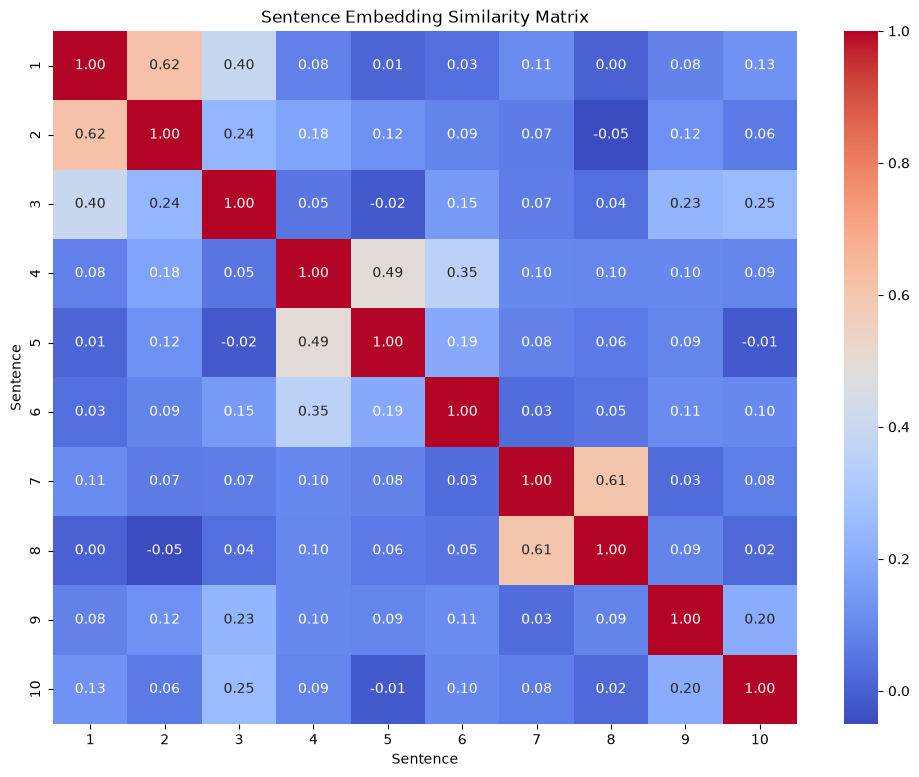

In [14]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=range(1, 11),
    yticklabels=range(1, 11)
)

plt.title("Sentence Embedding Similarity Matrix")
plt.xlabel("Sentence")
plt.ylabel("Sentence")
plt.show()

## Task 2 — Simple Semantic Search

In [15]:
knowledge_base = [
    "Machine learning algorithms learn patterns from training data.",
    "Supervised learning uses labeled datasets.",
    "Unsupervised learning discovers hidden patterns in data.",
    "Deep learning uses multiple layers of neural networks.",
    "Neural networks are inspired by the human brain.",
    "Python is commonly used for machine learning projects.",
    "Scikit-learn provides many machine learning algorithms.",
    "Natural language processing helps computers understand human language.",
    "Transformers are widely used in modern NLP applications.",
    "Text embeddings represent text as numerical vectors.",
    "Semantic search finds information based on meaning.",
    "Computer vision allows machines to analyze images.",
    "Data preprocessing improves the quality of machine learning data.",
    "Feature engineering creates useful features from raw data.",
    "Classification predicts categories or labels.",
    "Regression predicts continuous numerical values.",
    "Clustering groups similar data points together.",
    "Recommendation systems suggest relevant products or content.",
    "Healthy food provides vitamins and minerals.",
    "Fruits are an important part of a healthy diet.",
    "Vegetables contain important nutrients and fiber.",
    "Protein is important for maintaining muscles.",
    "Whole grains can be part of a balanced diet.",
    "Drinking enough water is important for health.",
    "A balanced diet includes different food groups.",
    "Healthy recipes often include fresh vegetables.",
    "Eating fruits can provide natural sources of vitamins.",
    "Nuts contain healthy fats and protein.",
    "Regular exercise supports physical health.",
    "Football is played by two teams.",
    "Cricket is popular in many countries.",
    "Basketball requires teamwork and coordination.",
    "Tennis is played using a racket and ball.",
    "Sports can improve physical fitness.",
    "Artificial intelligence enables machines to perform intelligent tasks.",
    "Large language models can generate and understand text.",
    "APIs allow software applications to communicate with each other.",
    "Databases store and organize information.",
    "Vector databases store and search numerical embeddings.",
    "Cloud computing provides computing resources over the internet.",
    "Cybersecurity protects systems from digital threats.",
    "Software development involves designing and building applications.",
    "Git is used for version control.",
    "GitHub hosts software repositories.",
    "Jupyter Notebook is useful for data science experiments.",
    "Data visualization helps communicate patterns in datasets.",
    "Statistics helps analyze and understand data.",
    "Linear regression is a common statistical learning method.",
    "Random forests combine multiple decision trees."
]

print("Knowledge base size:", len(knowledge_base))

Knowledge base size: 49


In [16]:
knowledge_embeddings = model.encode(
    knowledge_base,
    normalize_embeddings=True
)

print("Knowledge embeddings shape:", knowledge_embeddings.shape)

Knowledge embeddings shape: (49, 384)


In [17]:
def semantic_search(query, top_k=5):
    query_embedding = model.encode(
        [query],
        normalize_embeddings=True
    )[0]

    scores = np.dot(knowledge_embeddings, query_embedding)

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []

    for index in top_indices:
        results.append({
            "text": knowledge_base[index],
            "similarity": float(scores[index])
        })

    return results

In [18]:
query = "machine learning algorithms"

results = semantic_search(query, top_k=5)

print("Query:", query)
print("\nTop Results:\n")

for i, result in enumerate(results, start=1):
    print(f"{i}. {result['text']}")
    print(f"   Similarity: {result['similarity']:.4f}\n")

Query: machine learning algorithms

Top Results:

1. Machine learning algorithms learn patterns from training data.
   Similarity: 0.6507

2. Scikit-learn provides many machine learning algorithms.
   Similarity: 0.6139

3. Linear regression is a common statistical learning method.
   Similarity: 0.4665

4. Supervised learning uses labeled datasets.
   Similarity: 0.4557

5. Computer vision allows machines to analyze images.
   Similarity: 0.4448



In [19]:
query = "healthy food recipes"

results = semantic_search(query, top_k=5)

print("Query:", query)
print("\nTop Results:\n")

for i, result in enumerate(results, start=1):
    print(f"{i}. {result['text']}")
    print(f"   Similarity: {result['similarity']:.4f}\n")

Query: healthy food recipes

Top Results:

1. Healthy recipes often include fresh vegetables.
   Similarity: 0.7400

2. Healthy food provides vitamins and minerals.
   Similarity: 0.6306

3. Fruits are an important part of a healthy diet.
   Similarity: 0.5433

4. A balanced diet includes different food groups.
   Similarity: 0.5093

5. Whole grains can be part of a balanced diet.
   Similarity: 0.4694



In [20]:
test_queries = [
    "machine learning algorithms",
    "healthy food recipes"
]

for query in test_queries:
    results = semantic_search(query, top_k=3)

    print("=" * 70)
    print("Query:", query)

    for result in results:
        print(
            f"- {result['text']} "
            f"(score: {result['similarity']:.4f})"
        )

Query: machine learning algorithms
- Machine learning algorithms learn patterns from training data. (score: 0.6507)
- Scikit-learn provides many machine learning algorithms. (score: 0.6139)
- Linear regression is a common statistical learning method. (score: 0.4665)
Query: healthy food recipes
- Healthy recipes often include fresh vegetables. (score: 0.7400)
- Healthy food provides vitamins and minerals. (score: 0.6306)
- Fruits are an important part of a healthy diet. (score: 0.5433)


### Search Quality Evaluation

The semantic search system was tested using queries related to
machine learning and healthy food.

The returned results were semantically relevant to the queries.
This demonstrates that embeddings can retrieve information based
on meaning rather than exact keyword matching.

## Task 3 — Document Similarity Finder

In [21]:
documents = [
    """
    Machine learning is a branch of artificial intelligence that allows
    computers to learn patterns from data. Algorithms can be trained to
    make predictions and decisions without being explicitly programmed
    for every possible situation.
    """,

    """
    Machine learning algorithms learn useful patterns from datasets.
    Supervised learning uses labeled examples while unsupervised learning
    discovers patterns without labels.
    """,

    """
    Deep learning is a subfield of machine learning based on artificial
    neural networks with multiple layers. It is widely used in computer
    vision and natural language processing.
    """,

    """
    Natural language processing enables computers to process and understand
    human language. Modern NLP systems often use transformer architectures
    and text embeddings.
    """,

    """
    Text embeddings convert words, sentences, and documents into numerical
    vectors. Similar meanings are represented by vectors that are close
    together in vector space.
    """,

    """
    Healthy eating involves consuming a balanced variety of foods.
    Fruits, vegetables, whole grains, proteins, and healthy fats can
    contribute to a nutritious diet.
    """,

    """
    Fruits and vegetables provide vitamins, minerals, antioxidants, and
    dietary fiber. Eating a variety of plant foods can support a healthy
    lifestyle.
    """,

    """
    Regular exercise and a balanced diet are important components of a
    healthy lifestyle. Physical activity can improve fitness and overall
    well-being.
    """,

    """
    Football is a team sport played between two teams. Players work
    together to score goals while following the rules of the game.
    """,

    """
    Cricket is a bat-and-ball sport played between two teams. The objective
    is to score more runs than the opposing team.
    """,

    """
    Vector databases are designed to store and search high-dimensional
    numerical vectors. They are commonly used for semantic search and
    retrieval applications.
    """,

    """
    Semantic search retrieves information according to meaning rather than
    only matching exact keywords. Embeddings make semantic search possible
    by representing text as vectors.
    """
]

print("Number of documents:", len(documents))

Number of documents: 12


In [22]:
document_embeddings = model.encode(
    documents,
    normalize_embeddings=True
)

print("Document embedding shape:", document_embeddings.shape)

Document embedding shape: (12, 384)


In [23]:
document_similarity = np.dot(
    document_embeddings,
    document_embeddings.T
)

print("Similarity matrix shape:", document_similarity.shape)

Similarity matrix shape: (12, 12)


In [24]:
threshold = 0.50

similar_pairs = []

for i in range(len(documents)):
    for j in range(i + 1, len(documents)):
        score = document_similarity[i][j]

        if score >= threshold:
            similar_pairs.append((i, j, score))

similar_pairs = sorted(
    similar_pairs,
    key=lambda x: x[2],
    reverse=True
)

print("Similar document pairs:\n")

for i, j, score in similar_pairs:
    print(
        f"Document {i + 1} <-> Document {j + 1}: "
        f"{score:.4f}"
    )

Similar document pairs:

Document 1 <-> Document 2: 0.7007
Document 6 <-> Document 7: 0.6875
Document 5 <-> Document 12: 0.6206
Document 6 <-> Document 8: 0.6105
Document 4 <-> Document 5: 0.6005
Document 1 <-> Document 3: 0.5692
Document 4 <-> Document 12: 0.5503
Document 11 <-> Document 12: 0.5327


In [25]:
duplicate_threshold = 0.95

duplicates = []

for i in range(len(documents)):
    for j in range(i + 1, len(documents)):
        score = document_similarity[i][j]

        if score > duplicate_threshold:
            duplicates.append((i, j, score))

print("Near-duplicate documents:")

if duplicates:
    for i, j, score in duplicates:
        print(
            f"Document {i + 1} <-> Document {j + 1}: "
            f"{score:.4f}"
        )
else:
    print("No near-duplicate documents found.")

Near-duplicate documents:
No near-duplicate documents found.


In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

documents_2d = pca.fit_transform(document_embeddings)

print("2D shape:", documents_2d.shape)

2D shape: (12, 2)


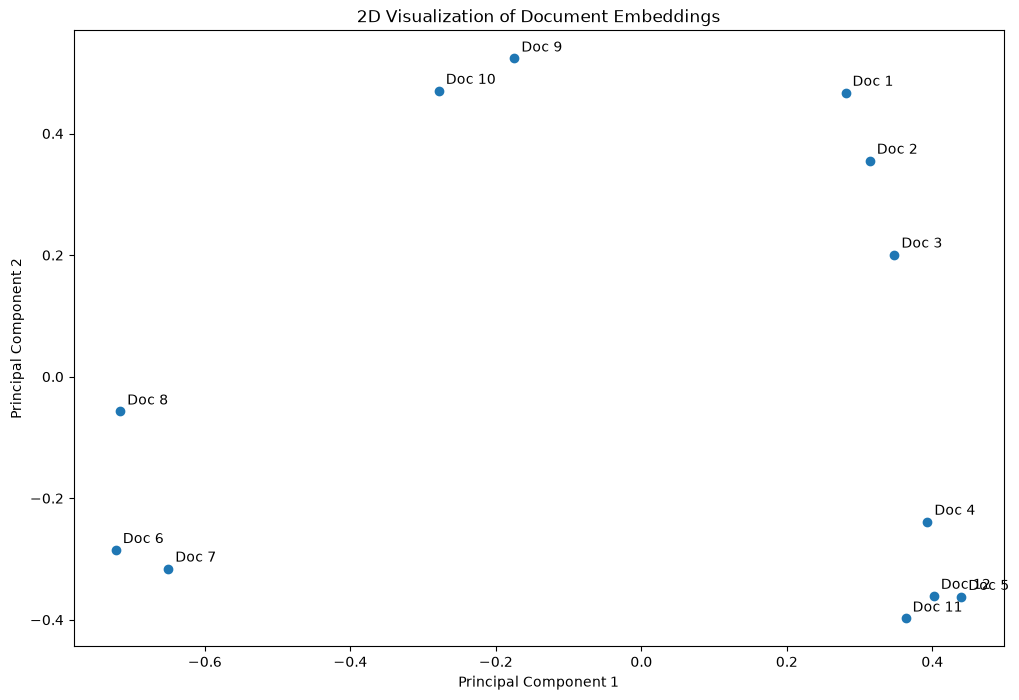

In [27]:
plt.figure(figsize=(12, 8))

plt.scatter(
    documents_2d[:, 0],
    documents_2d[:, 1]
)

for i in range(len(documents)):
    plt.annotate(
        f"Doc {i + 1}",
        (documents_2d[i, 0], documents_2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("2D Visualization of Document Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [28]:
print("========== EMBEDDING PROJECT RESULTS ==========")

print("\nTask 1:")
print("Dog vs Puppy similarity:", round(similarity_dog_puppy, 4))
print("Dog vs Car similarity:", round(similarity_dog_car, 4))

print("\nTask 2:")
print("Knowledge base documents:", len(knowledge_base))
print("Semantic search completed successfully.")

print("\nTask 3:")
print("Documents analyzed:", len(documents))
print("Document embeddings shape:", document_embeddings.shape)
print("Near duplicates found:", len(duplicates))

print("\nAll tasks completed successfully!")

========== EMBEDDING PROJECT RESULTS ==========

Task 1:
Dog vs Puppy similarity: 0.5977
Dog vs Car similarity: 0.0047

Task 2:
Knowledge base documents: 49
Semantic search completed successfully.

Task 3:
Documents analyzed: 12
Document embeddings shape: (12, 384)
Near duplicates found: 0

All tasks completed successfully!


## Conclusion

This project demonstrated how text embeddings can represent semantic
meaning as numerical vectors. Similar texts produced higher cosine
similarity scores, while unrelated texts generally produced lower scores.

A simple semantic search system was implemented using embeddings and
cosine similarity. The system successfully retrieved semantically
relevant information for machine learning and healthy food queries.

Document embeddings were also generated to identify similar documents
and detect potential near-duplicates. Finally, dimensionality reduction
was used to visualize document embeddings in two dimensions.

### Key Learning

- Embeddings represent semantic meaning numerically.
- Cosine similarity can measure semantic similarity.
- Semantic search does not depend only on exact keyword matching.
- Vector databases are useful for efficient large-scale vector search.
- Embeddings can be used for document similarity and duplicate detection.